<a href="https://colab.research.google.com/github/Priyan437/Credit-Risk-Analysis-Model/blob/main/Credit_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Importing of all the Necessary Libraries for Visualisation and Preprocessing is imported.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [ ]:
## Data is loaded in df name object and then first top 5 data is printed.

df = pd.read_csv('/(Copy) loan_data_2007_2014.csv')
df.head()

/tmp/ipykernel_6356/2546651312.py:3: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/(Copy) loan_data_2007_2014.csv')


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
## To display all the columns at once we are changing the display preference.

pd.options.display.max_columns = None

In [ ]:
##Displaying of random any 2 sample data points.

df.sample(2)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
434006,434006,12487664,14499786,21000,21000,21000.0,36 months,6.62,644.78,A,A2,Engineer,9 years,MORTGAGE,80000.0,Source Verified,Mar-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,156xx,PA,26.58,0.0,Jul-99,0.0,NaN,NaN,12.0,0.0,31627,48.3,20.0,w,8664.05,8664.05,14206.26,14206.26,12335.95,1870.31,0.0,0.0,0.0,Jan-16,644.78,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,112752.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65500.0,NaN,NaN,NaN
346839,346839,21080580,23363301,27650,27650,27625.0,60 months,16.99,687.03,D,D3,Driver,1 year,MORTGAGE,63000.0,Source Verified,Jul-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,975xx,OR,20.50,0.0,Feb-01,0.0,NaN,NaN,12.0,0.0,4392,48.8,17.0,f,22014.16,21994.26,11679.51,11668.95,5635.84,6043.67,0.0,0.0,0.0,Dec-15,687.03,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,0.0,166402.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9000.0,NaN,NaN,NaN


In [ ]:
##Seeing in the How many null data points is there in each column individually.

df.isnull().sum().values

array([     0,      0,      0,      0,      0,      0,      0,      0,
            0,      0,      0,  27588,  21008,      0,      4,      0,
            0,      0,      0,      0, 340304,      0,     21,      0,
            0,      0,     29,     29,     29, 250351, 403647,     29,
           29,      0,    340,     29,      0,      0,      0,      0,
            0,      0,      0,      0,      0,      0,    376,      0,
       227214,     42,    145, 367311,      0,      0, 466285, 466285,
       466285,     29,  70276,  70276, 466285, 466285, 466285, 466285,
       466285, 466285, 466285, 466285, 466285, 466285, 466285,  70276,
       466285, 466285, 466285])

In [ ]:
## Seeing the name of all the columns.

df.columns.values

array(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'veri

In [ ]:
## for Seeing the Data Types and null values Count

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [ ]:
##Seeing the shape of the data

df.shape

(466285, 75)

In [ ]:
## Making the copy of the dataset in the loan_data so that we cannot morph the original Loaded data.

loan_data = df.copy()
loan_data.sample(1)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
302016,302016,28382490,30905604,24000,24000,24000.0,60 months,19.52,629.47,E,E2,Senior Superintendent,4 years,MORTGAGE,135000.0,Verified,Oct-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,NaN,debt_consolidation,Debt consolidation,372xx,TN,32.74,0.0,Aug-90,1.0,37.0,NaN,11.0,0.0,87685,70.6,34.0,w,19975.38,19975.38,9442.05,9442.05,4024.62,5417.43,0.0,0.0,0.0,Jan-16,629.47,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,601.0,324134.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98500.0,NaN,NaN,NaN


In [ ]:
loan_data['emp_length'].unique()

array(['10+ years', '< 1 year', '1 year', '3 years', '8 years', '9 years',
       '4 years', '5 years', '6 years', '2 years', '7 years', nan],
      dtype=object)

In [ ]:
loan_data['emp_length_int'] =  loan_data['emp_length']

loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('\+ years', '')
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace(' years', '')
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace(' year', '')
loan_data['emp_length_int'] = loan_data['emp_length_int'].fillna(str(0))
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace( 'n/a' , str(0))
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('< 1 year', str(0))

<>:3: SyntaxWarning: invalid escape sequence '\+'
<>:3: SyntaxWarning: invalid escape sequence '\+'
/tmp/ipykernel_6356/2070441519.py:3: SyntaxWarning: invalid escape sequence '\+'
  loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('\+ years', '')


In [ ]:
loan_data['emp_length_int'].unique()

array(['10+', '< 1', '1', '3', '8', '9', '4', '5', '6', '2', '7', '0'],
      dtype=object)

In [ ]:
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('< ', '')
loan_data['emp_length_int'] = loan_data['emp_length_int'].str.replace('+', '')

In [ ]:
loan_data['emp_length_int'].unique()

array(['10', '1', '3', '8', '9', '4', '5', '6', '2', '7', '0'],
      dtype=object)

In [ ]:
type(loan_data['emp_length_int'][0])

str

In [ ]:
loan_data['emp_length_int'] = pd.to_numeric(loan_data['emp_length_int'])

In [ ]:
type(loan_data['emp_length_int'][0])

numpy.int64

In [ ]:
loan_data['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [ ]:
loan_data['term_int'] = loan_data['term']
loan_data['term_int'] = loan_data['term_int'].str.replace(' months', '')
loan_data['term_int'] = loan_data['term_int'].str.replace(' ', '')


In [ ]:
loan_data['term_int'].unique()
loan_data['term_int'] = pd.to_numeric(loan_data['term_int'])
type(loan_data['term_int'][0])

numpy.int64

In [ ]:
print(loan_data['earliest_cr_line'])

0         Jan-85
1         Apr-99
2         Nov-01
3         Feb-96
4         Jan-96
           ...  
466280    Apr-03
466281    Jun-97
466282    Dec-01
466283    Feb-03
466284    Feb-00
Name: earliest_cr_line, Length: 466285, dtype: object


In [ ]:
loan_data['earliest_cr_line_date'] = pd.to_datetime(
    loan_data['earliest_cr_line'],
    format='%b-%y'
)

loan_data['mnth_earliest_cr_line'] = (
    (pd.to_datetime('2017-12-01').year - loan_data['earliest_cr_line_date'].dt.year) * 12
    +
    (pd.to_datetime('2017-12-01').month - loan_data['earliest_cr_line_date'].dt.month)
)

In [ ]:
loan_data['mnth_earliest_cr_line'].describe()

,mnth_earliest_cr_line
count,466256.000000
mean,239.482430
std,93.974829
min,-612.000000
25%,183.000000
50%,225.000000
75%,285.000000
max,587.000000


In [ ]:
loan_data.loc[ : , ['earliest_cr_line','earliest_cr_line_date','mnth_earliest_cr_line']][loan_data['mnth_earliest_cr_line'] < 0 ]

,earliest_cr_line,earliest_cr_line_date,mnth_earliest_cr_line
1580,Sep-62,2062-09-01,-537.0
1770,Sep-68,2068-09-01,-609.0
2799,Sep-64,2064-09-01,-561.0
3282,Sep-67,2067-09-01,-597.0
3359,Feb-65,2065-02-01,-566.0
...,...,...,...
464003,Jan-68,2068-01-01,-601.0
464260,Jul-66,2066-07-01,-583.0
465100,Oct-67,2067-10-01,-598.0
465500,Sep-67,2067-09-01,-597.0


In [ ]:
loan_data['mnth_earliest_cr_line'][loan_data['mnth_earliest_cr_line']  < 0] = loan_data['mnth_earliest_cr_line'].max()

/tmp/ipykernel_6356/3066867892.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  loan_data['mnth_earliest_cr_line'][loan_data['mnth_earliest_cr_line']  < 0] = loan_data['mnth_earliest_cr_line'].max()
/tmp/ipykernel_6356/3066867892.py:1: Se

In [ ]:
print(type(loan_data['issue_d'][0]))
print(loan_data['issue_d'][0])

<class 'str'>
Dec-11


In [ ]:
loan_data['issue_d_date'] = pd.to_datetime(loan_data['issue_d'] , format = '%b-%y')
type(loan_data['issue_d_date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [ ]:
loan_data['issue_d_date_mnth'] = (
                                 (pd.to_datetime('2017-12-01').year - loan_data['issue_d_date'].dt.year) * 12
                                 +
                                 (pd.to_datetime('2017-12-01').month - loan_data['issue_d_date'].dt.month)
                                 )

In [ ]:
loan_data['issue_d_date_mnth'].describe()

,issue_d_date_mnth
count,466285.000000
mean,51.255187
std,14.340154
min,36.000000
25%,41.000000
50%,47.000000
75%,57.000000
max,126.000000


Preprocessing to Discrete Variables that is making the Categorical Variable to Machine understandable Numerical value Dummy Varible(Applying One Hot Encoding).

In [ ]:
loan_data_dummies =  [pd.get_dummies(loan_data['grade'], dtype = int, prefix = 'grade', prefix_sep = ':'),
pd.get_dummies(loan_data['sub_grade'], dtype = int, prefix = 'sub_grade', prefix_sep = ':'),
pd.get_dummies(loan_data['home_ownership'], dtype = int, prefix = 'home_ownership', prefix_sep = ':'),
pd.get_dummies(loan_data['verification_status'], dtype = int, prefix = 'verification_status', prefix_sep = ':'),
pd.get_dummies(loan_data['loan_status'], dtype = int, prefix = 'loan_status', prefix_sep = ':'),
pd.get_dummies(loan_data['purpose'], dtype = int, prefix = 'purpose', prefix_sep = ':'),
pd.get_dummies(loan_data['addr_state'], dtype = int, prefix = 'addr_state', prefix_sep = ':'),
pd.get_dummies(loan_data['initial_list_status'], dtype = int, prefix = 'initial_list_status', prefix_sep = ':')]

In [ ]:
loan_data_dummies[0]

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G
0,0,1,0,0,0,0,0
1,0,0,1,0,0,0,0
2,0,0,1,0,0,0,0
3,0,0,1,0,0,0,0
4,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...
466280,0,0,1,0,0,0,0
466281,0,0,0,1,0,0,0
466282,0,0,0,1,0,0,0
466283,1,0,0,0,0,0,0


In [ ]:
loan_data_dummies = pd.concat(loan_data_dummies, axis = 1)
loan_data = pd.concat([loan_data,loan_data_dummies], axis = 1)


In [ ]:
pd.options.display.max_rows = None
loan_data.isnull().sum()

,0
Unnamed: 0,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0


In [ ]:
loan_data['total_rev_hi_lim'].fillna(loan_data['funded_amnt'], inplace = True)
loan_data['annual_inc'].fillna(loan_data['annual_inc'].mean(), inplace = True)
loan_data['mnth_earliest_cr_line'].fillna(0, inplace = True)
loan_data['acc_now_delinq'].fillna(0, inplace = True)
loan_data['total_acc'].fillna(0, inplace = True)
loan_data['open_acc'].fillna(0, inplace = True)
loan_data['pub_rec'].fillna(0, inplace = True)
loan_data['inq_last_6mths'].fillna(0, inplace = True)
loan_data['delinq_2yrs'].fillna(0, inplace = True)
loan_data['emp_length_int'].fillna(0, inplace = True)

/tmp/ipykernel_6356/1157520398.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data['total_rev_hi_lim'].fillna(loan_data['funded_amnt'], inplace = True)
/tmp/ipykernel_6356/1157520398.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [ ]:
pd.options.display.max_rows = None
loan_data.isnull().sum()

,0
Unnamed: 0,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0


In [ ]:
pd.options.display.max_rows = 100

 **PD MODEL**

Data Preperation

In [ ]:
loan_data['loan_status'].value_counts() / loan_data['loan_status'].count() * 100

,count
loan_status,
Current,48.087757
Fully Paid,39.619332
Charged Off,9.109236
Late (31-120 days),1.479782
In Grace Period,0.674695
Does not meet the credit policy. Status:Fully Paid,0.426349
Late (16-30 days),0.261214
Default,0.178432
Does not meet the credit policy. Status:Charged Off,0.163205


In [ ]:
loan_data['good_bad'] = np.where(loan_data['loan_status'].isin(['Charged Off','Late (31-120 days)','Default',
                                                                'Does not meet the credit policy. Status:Charged Off']
                                                               ), 0 , 1)

In [ ]:
loan_data['good_bad'].head()

,good_bad
0,1
1,0
2,1
3,1
4,1


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(loan_data.iloc[:,:-1], loan_data.iloc[:,-1], test_size = 0.2, random_state = 42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(373028, 207)
(93257, 207)
(373028,)
(93257,)


In [ ]:
## Calculation of WoE and IV Values for discrete Variable Function.

def woe_discrete(dataset, discrete_variable_name, dataset2):
  dataset = pd.concat([dataset[discrete_variable_name],dataset2],axis = 1)
  dataset = pd.concat([dataset.groupby(dataset.columns.values[0], as_index = False)[dataset.columns.values[1]].count(),
                       dataset.groupby(dataset.columns.values[0], as_index = False)[dataset.columns.values[1]].mean()], axis = 1)
  dataset = dataset.iloc[:,[0,1,3]]
  dataset.columns = [dataset.columns.values[0], 'n_obs', 'prop_good']
  dataset['prop_n_obs'] = dataset['n_obs'] / dataset['n_obs'].sum()
  dataset['n_good'] = dataset['prop_good'] * dataset['n_obs']
  dataset['n_bad'] = (1 - dataset['prop_good']) * dataset['n_obs']
  dataset['prop_n_good'] = dataset['n_good'] / dataset['n_good'].sum()
  dataset['prop_n_bad'] = dataset['n_bad'] / dataset['n_bad'].sum()
  dataset['WoE'] = np.log(dataset['prop_n_good']/dataset['prop_n_bad'])
  dataset = dataset.sort_values('WoE')
  dataset = dataset.reset_index(drop = True)
  dataset['diff_prop_good'] = dataset['prop_good'].diff().abs()
  dataset['diff_WoE'] = dataset['WoE'].diff().abs()
  dataset['IV'] = (dataset['prop_n_good'] - dataset['prop_n_bad']) * dataset['WoE']
  dataset['IV'] = dataset['IV'].sum()
  return dataset

In [ ]:
df_temp = woe_discrete(x_train, 'grade', y_train)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2654,0.727958,0.007115,1932.0,722.0,0.005815,0.017706,-1.113459,NaN,NaN,0.288636
1,F,10530,0.754416,0.028228,7944.0,2586.0,0.023910,0.063417,-0.975440,0.026458,0.138019,0.288636
2,E,28612,0.805257,0.076702,23040.0,5572.0,0.069345,0.136642,-0.678267,0.050841,0.297173,0.288636
3,D,61498,0.846304,0.164862,52046.0,9452.0,0.156647,0.231792,-0.391843,0.041047,0.286424,0.288636
4,C,100245,0.885770,0.268733,88794.0,11451.0,0.267251,0.280813,-0.049503,0.039466,0.342340,0.288636
5,B,109730,0.921015,0.294160,101063.0,8667.0,0.304178,0.212541,0.358476,0.035245,0.407979,0.288636
6,A,59759,0.961044,0.160200,57431.0,2328.0,0.172855,0.057090,1.107830,0.040028,0.749353,0.288636


In [ ]:
def plot_by_WoE(df_WoE , rotation_of_x_axis_labels = 0):
  x = np.array(df_WoE.iloc[:,0].apply(str))
  y = df_WoE['WoE']
  plt.figure( figsize = (18,6))
  plt.plot(x,y,marker = 'o', linestyle = '--', color = 'k')
  plt.xlabel(df_WoE.columns[0])
  plt.ylabel('Weight of Evidence')
  plt.xticks(rotation = rotation_of_x_axis_labels)
  plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))

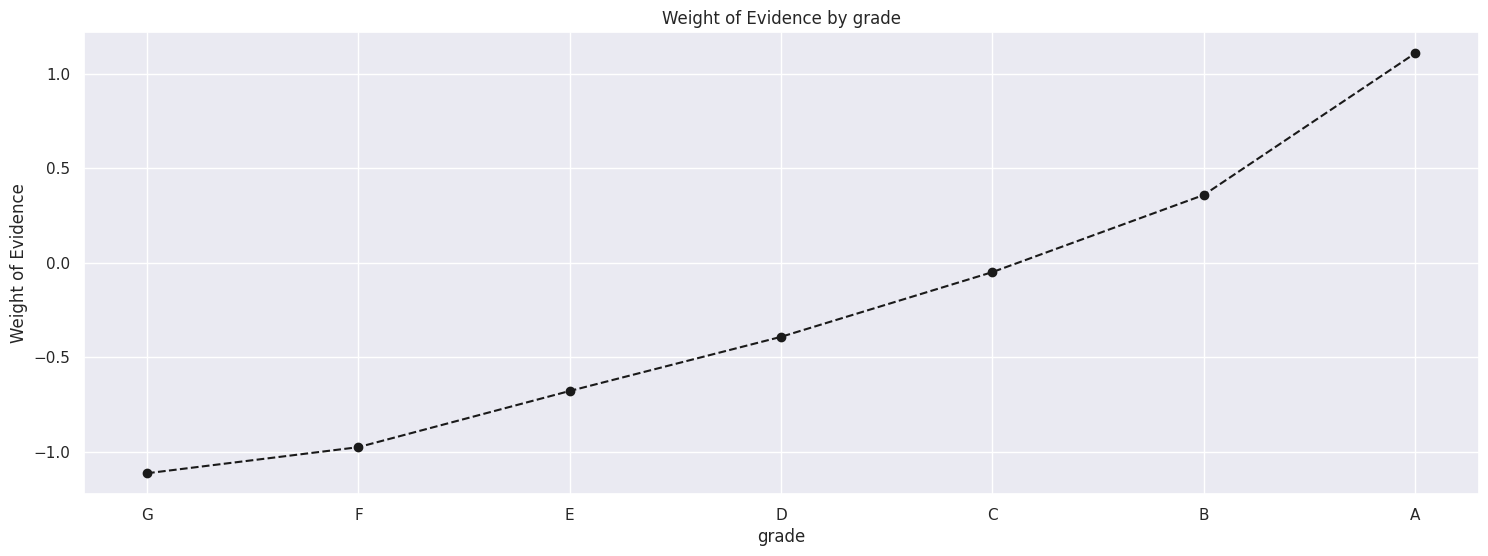

In [ ]:
plot_by_WoE(df_temp)

In [ ]:
df_temp = woe_discrete(x_train, 'home_ownership', y_train)
df_temp

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,OTHER,137,0.795620,0.000367,109.0,28.0,0.000328,0.000687,-0.738602,NaN,NaN,inf
1,NONE,40,0.850000,0.000107,34.0,6.0,0.000102,0.000147,-0.363144,0.054380,0.375458,inf
2,RENT,150599,0.873870,0.403720,131604.0,18995.0,0.396099,0.465815,-0.162123,0.023870,0.201021,inf
3,OWN,33295,0.892536,0.089256,29717.0,3578.0,0.089442,0.087743,0.019170,0.018666,0.181294,inf
4,MORTGAGE,188956,0.903835,0.506546,170785.0,18171.0,0.514026,0.445608,0.142834,0.011298,0.123663,inf
5,ANY,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,0.096165,inf,inf


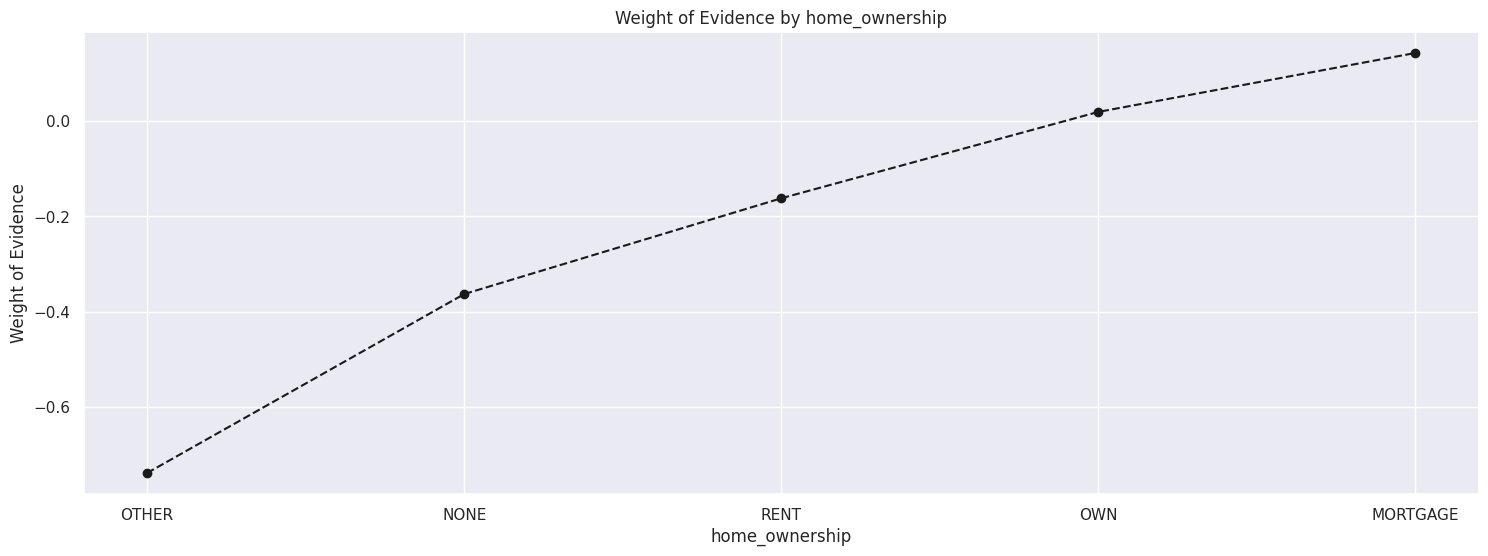

In [ ]:
plot_by_WoE(df_temp)

In [ ]:
x_train['home_ownership:RENT_OTHER_NONE ANY'] = sum([x_train['home_ownership:RENT'],x_train['home_ownership:OTHER'],
                                                             x_train['home_ownership:NONE'],x_train['home_ownership:ANY']])

In [ ]:
x_train['addr_state'].unique()

array(['SC', 'NJ', 'GA', 'MA', 'CA', 'IL', 'NC', 'NY', 'TX', 'CT', 'FL',
       'VA', 'UT', 'AZ', 'MD', 'WI', 'MI', 'CO', 'TN', 'IN', 'AL', 'NV',
       'MT', 'RI', 'OR', 'MN', 'KS', 'AK', 'PA', 'OH', 'WA', 'KY', 'OK',
       'MO', 'NM', 'HI', 'WV', 'LA', 'VT', 'AR', 'DC', 'SD', 'NH', 'WY',
       'MS', 'DE', 'IA', 'NE', 'ID', 'ME'], dtype=object)

In [ ]:
df_temp = woe_discrete(x_train, 'addr_state', y_train)
df_temp

,addr_state,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,NE,13,0.461538,0.000035,6.0,7.0,0.000018,0.000172,-2.251896,NaN,NaN,inf
1,IA,13,0.769231,0.000035,10.0,3.0,0.000030,0.000074,-0.893772,0.307692,1.358123,inf
2,NV,5221,0.864585,0.013996,4514.0,707.0,0.013586,0.017338,-0.243837,0.095355,0.649935,inf
3,FL,25211,0.875808,0.067585,22080.0,3131.0,0.066456,0.076782,-0.144425,0.011223,0.099411,inf
4,HI,2001,0.877061,0.005364,1755.0,246.0,0.005282,0.006033,-0.132852,0.001253,0.011573,inf
5,AL,4671,0.877328,0.012522,4098.0,573.0,0.012334,0.014052,-0.130376,0.000267,0.002476,inf
6,NM,2075,0.883373,0.005563,1833.0,242.0,0.005517,0.005935,-0.072973,0.006045,0.057403,inf
7,VA,11366,0.883864,0.030470,10046.0,1320.0,0.030236,0.032370,-0.068202,0.000491,0.004771,inf
8,NY,32211,0.883984,0.086350,28474.0,3737.0,0.085701,0.091643,-0.067037,0.000120,0.001165,inf
9,OK,3284,0.884287,0.008804,2904.0,380.0,0.008740,0.009319,-0.064072,0.000304,0.002965,inf


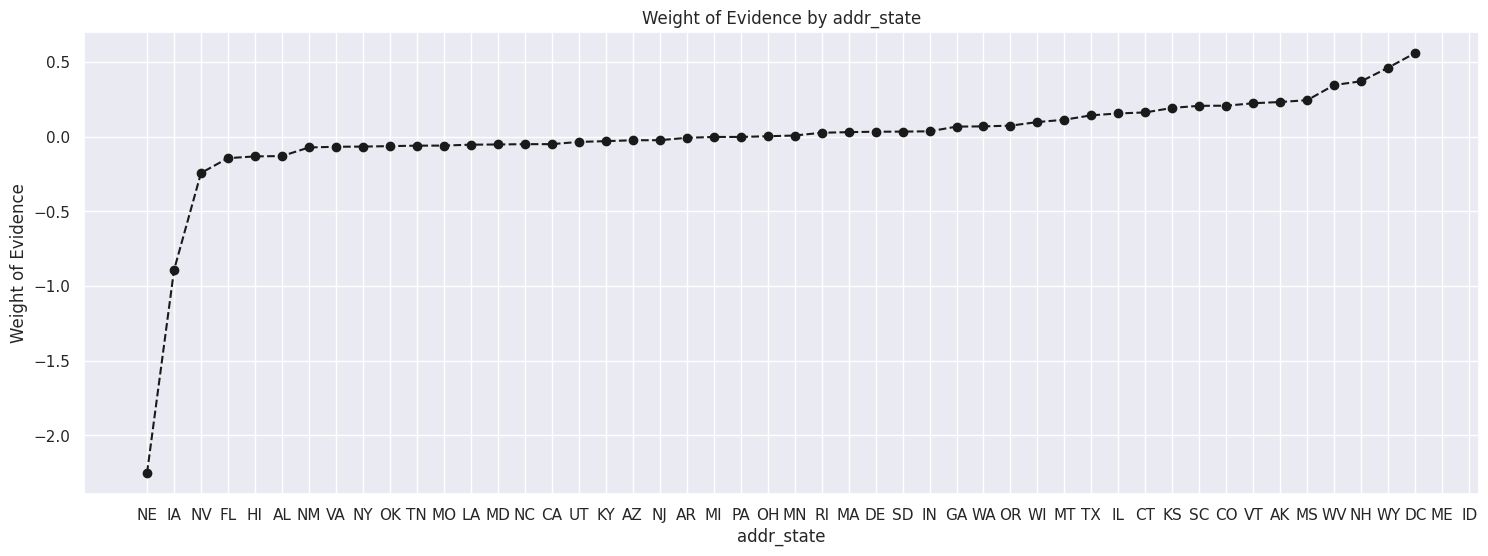

In [ ]:
plot_by_WoE(df_temp)

In [ ]:
if ['addr_state:ND'] in x_train.columns.values:
    pass
else:
    x_train['addr_state:ND'] = 0

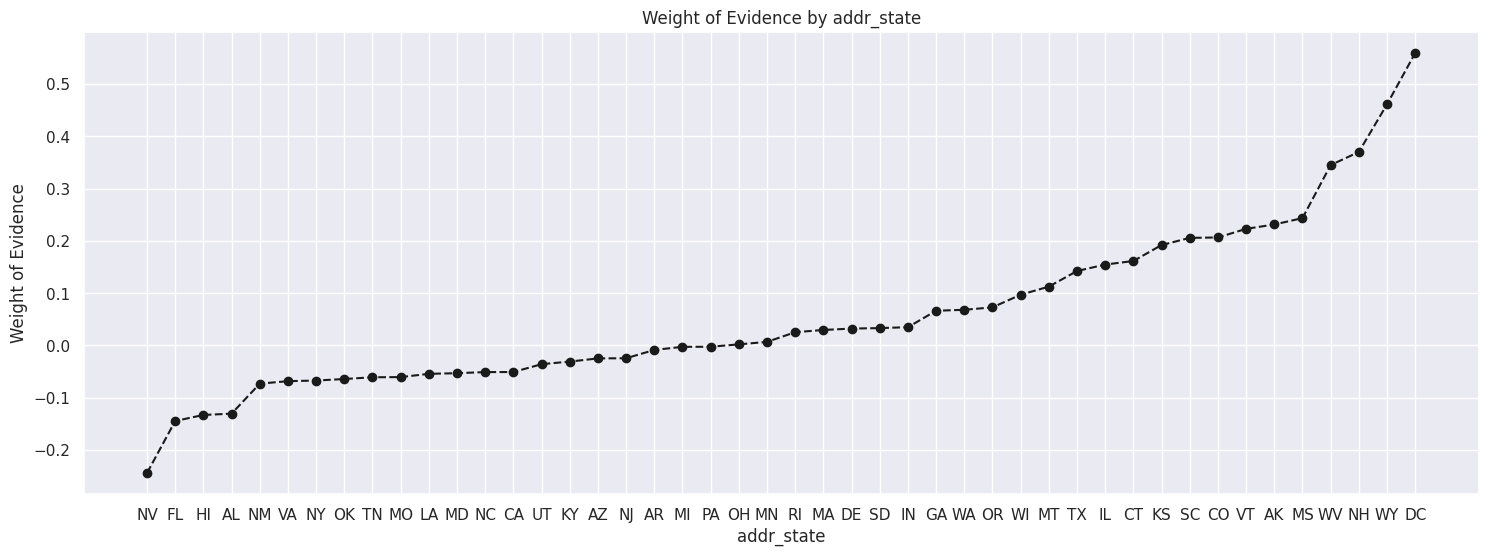

In [ ]:
plot_by_WoE(df_temp.iloc[2: -2, : ])
# We plot the weight of evidence values.

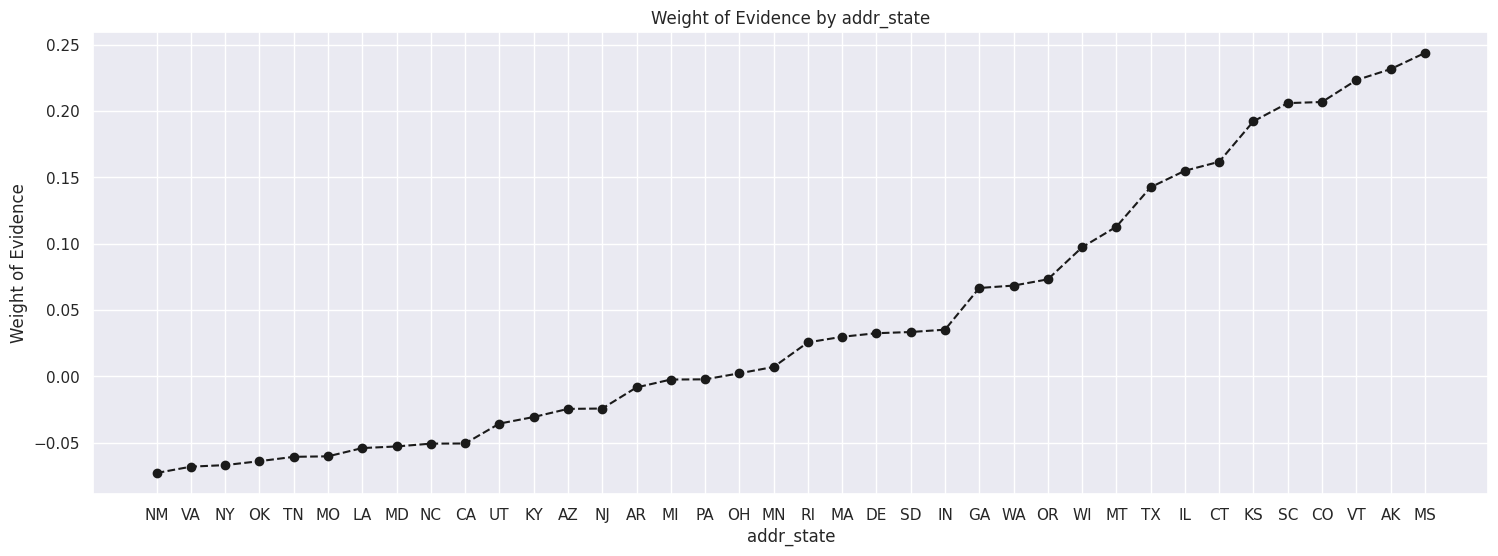

In [ ]:
plot_by_WoE(df_temp.iloc[6: -6, : ])
# We plot the weight of evidence values.

In [ ]:
# We create the following categories:
# 'ND' 'NE' 'IA' NV' 'FL' 'HI' 'AL'
# 'NM' 'VA'
# 'NY'
# 'OK' 'TN' 'MO' 'LA' 'MD' 'NC'
# 'CA'
# 'UT' 'KY' 'AZ' 'NJ'
# 'AR' 'MI' 'PA' 'OH' 'MN'
# 'RI' 'MA' 'DE' 'SD' 'IN'
# 'GA' 'WA' 'OR'
# 'WI' 'MT'
# 'TX'
# 'IL' 'CT'
# 'KS' 'SC' 'CO' 'VT' 'AK' 'MS'
# 'WV' 'NH' 'WY' 'DC' 'ME' 'ID'

# 'IA_NV_HI_ID_AL_FL' will be the reference category.

x_train['addr_state:ND_NE_IA_NV_FL_HI_AL'] = sum([x_train['addr_state:ND'], x_train['addr_state:NE'],
                                              x_train['addr_state:IA'], x_train['addr_state:NV'],
                                              x_train['addr_state:FL'], x_train['addr_state:HI'],
                                                          x_train['addr_state:AL']])

x_train['addr_state:NM_VA'] = sum([x_train['addr_state:NM'], x_train['addr_state:VA']])

x_train['addr_state:OK_TN_MO_LA_MD_NC'] = sum([x_train['addr_state:OK'], x_train['addr_state:TN'],
                                              x_train['addr_state:MO'], x_train['addr_state:LA'],
                                              x_train['addr_state:MD'], x_train['addr_state:NC']])

x_train['addr_state:UT_KY_AZ_NJ'] = sum([x_train['addr_state:UT'], x_train['addr_state:KY'],
                                              x_train['addr_state:AZ'], x_train['addr_state:NJ']])

x_train['addr_state:AR_MI_PA_OH_MN'] = sum([x_train['addr_state:AR'], x_train['addr_state:MI'],
                                              x_train['addr_state:PA'], x_train['addr_state:OH'],
                                              x_train['addr_state:MN']])

x_train['addr_state:RI_MA_DE_SD_IN'] = sum([x_train['addr_state:RI'], x_train['addr_state:MA'],
                                              x_train['addr_state:DE'], x_train['addr_state:SD'],
                                              x_train['addr_state:IN']])

x_train['addr_state:GA_WA_OR'] = sum([x_train['addr_state:GA'], x_train['addr_state:WA'],
                                              x_train['addr_state:OR']])

x_train['addr_state:WI_MT'] = sum([x_train['addr_state:WI'], x_train['addr_state:MT']])

x_train['addr_state:IL_CT'] = sum([x_train['addr_state:IL'], x_train['addr_state:CT']])

x_train['addr_state:KS_SC_CO_VT_AK_MS'] = sum([x_train['addr_state:KS'], x_train['addr_state:SC'],
                                              x_train['addr_state:CO'], x_train['addr_state:VT'],
                                              x_train['addr_state:AK'], x_train['addr_state:MS']])

x_train['addr_state:WV_NH_WY_DC_ME_ID'] = sum([x_train['addr_state:WV'], x_train['addr_state:NH'],
                                              x_train['addr_state:WY'], x_train['addr_state:DC'],
                                              x_train['addr_state:ME'], x_train['addr_state:ID']])

In [ ]:
df_temp = woe_discrete(x_train, 'verification_status', y_train)
df_temp

,verification_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,Verified,134414,0.872781,0.360332,117314.0,17100.0,0.353090,0.419344,-0.171969,NaN,NaN,0.020384
1,Source Verified,120030,0.895918,0.321772,107537.0,12493.0,0.323663,0.306366,0.054922,0.023137,0.226891,0.020384
2,Not Verified,118584,0.905679,0.317896,107399.0,11185.0,0.323248,0.274290,0.164232,0.009761,0.109311,0.020384


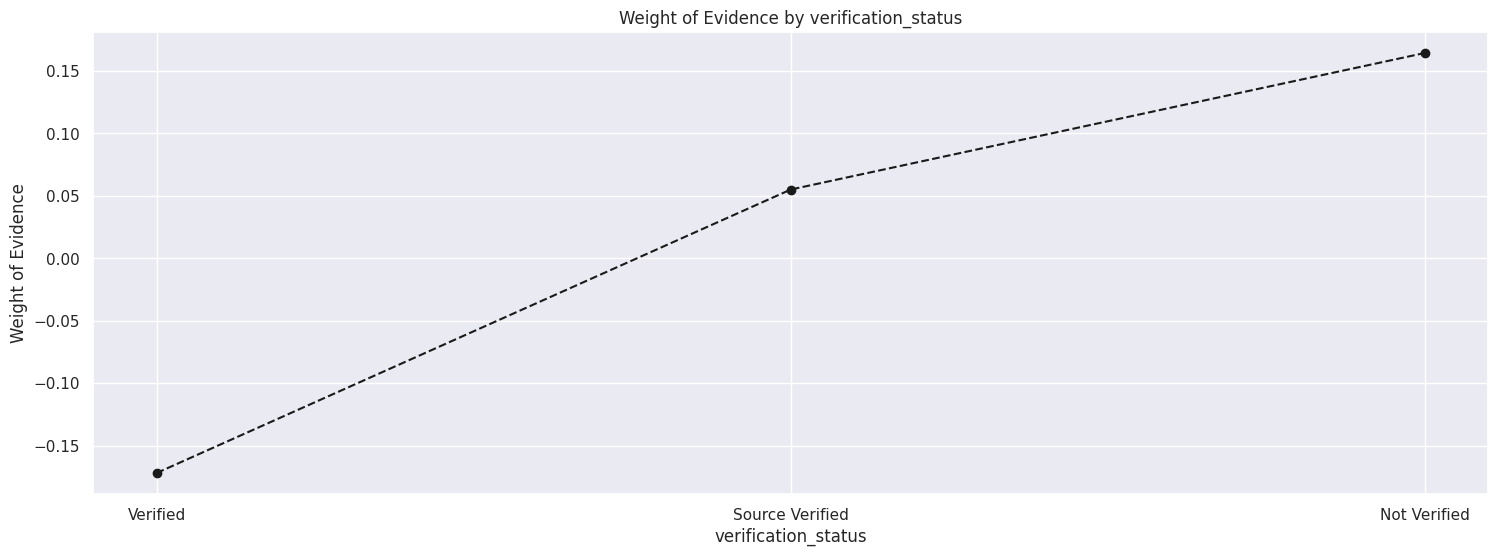

In [ ]:
plot_by_WoE(df_temp)

In [ ]:
df_temp = woe_discrete(x_train, 'purpose', y_train)
df_temp

,purpose,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,small_business,5582,0.786098,0.014964,4388.0,1194.0,0.013207,0.029280,-0.796180,NaN,NaN,0.035418
1,educational,333,0.801802,0.000893,267.0,66.0,0.000804,0.001619,-0.700151,0.015704,0.096029,0.035418
2,moving,2392,0.839465,0.006412,2008.0,384.0,0.006044,0.009417,-0.443493,0.037663,0.256658,0.035418
3,house,1830,0.860109,0.004906,1574.0,256.0,0.004737,0.006278,-0.281547,0.020644,0.161946,0.035418
4,other,18884,0.862264,0.050624,16283.0,2601.0,0.049008,0.063784,-0.263519,0.002155,0.018028,0.035418
5,renewable_energy,281,0.864769,0.000753,243.0,38.0,0.000731,0.000932,-0.242270,0.002504,0.021250,0.035418
6,medical,3684,0.868350,0.009876,3199.0,485.0,0.009628,0.011894,-0.211300,0.003581,0.030969,0.035418
7,wedding,1887,0.881823,0.005059,1664.0,223.0,0.005008,0.005469,-0.087937,0.013473,0.123363,0.035418
8,vacation,1991,0.882471,0.005337,1757.0,234.0,0.005288,0.005738,-0.081703,0.000648,0.006234,0.035418
9,debt_consolidation,219183,0.886884,0.587578,194390.0,24793.0,0.585071,0.607999,-0.038440,0.004413,0.043263,0.035418


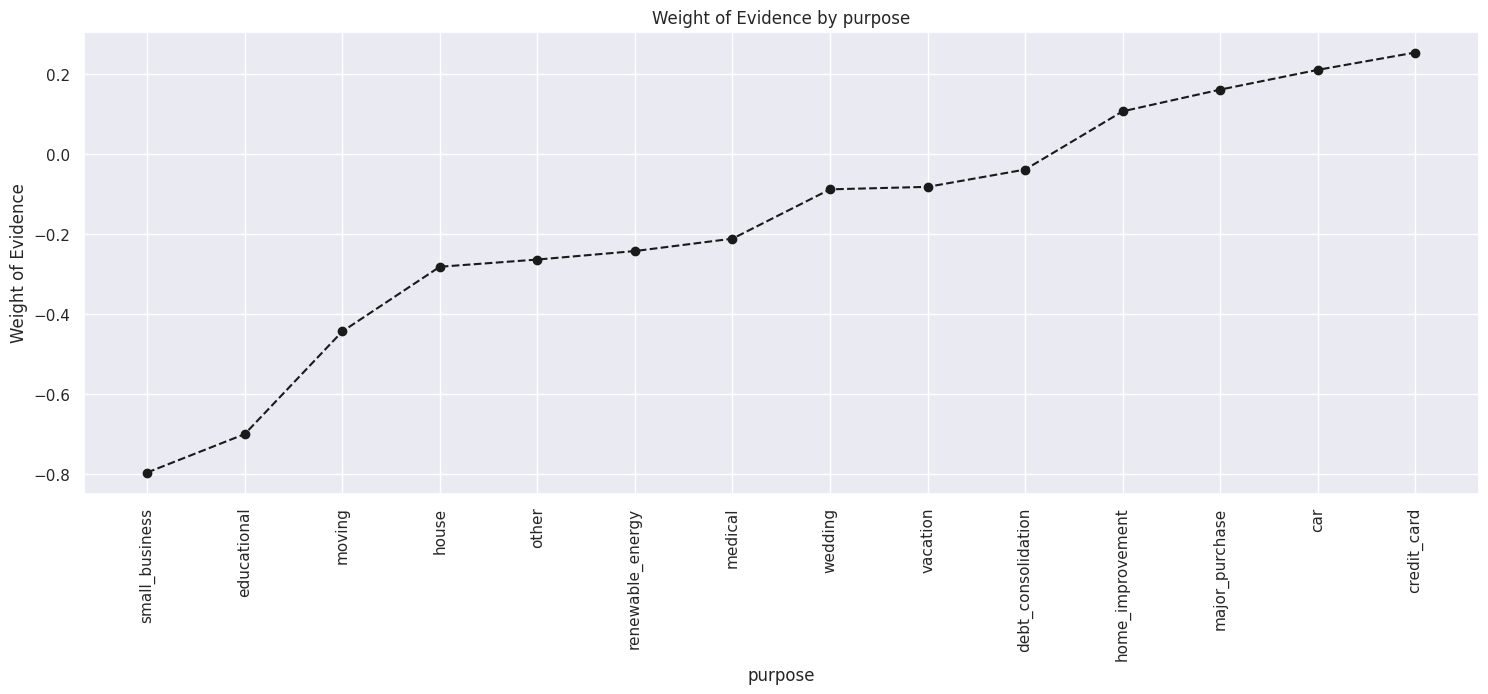

In [ ]:
plot_by_WoE(df_temp , 90)

In [ ]:
x_train['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([x_train['purpose:educational'], x_train['purpose:small_business'],
                                                                 x_train['purpose:wedding'], x_train['purpose:renewable_energy'],
                                                                 x_train['purpose:moving'], x_train['purpose:house']])
x_train['purpose:oth__med__vacation'] = sum([x_train['purpose:other'], x_train['purpose:medical'],
                                             x_train['purpose:vacation']])
x_train['purpose:major_purch__car__home_impr'] = sum([x_train['purpose:major_purchase'], x_train['purpose:car'],
                                                        x_train['purpose:home_improvement']])

In [ ]:
df_temp = woe_discrete(x_train, 'initial_list_status', y_train)
df_temp

,initial_list_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,f,242514,0.879694,0.650123,213338.0,29176.0,0.642101,0.715484,-0.108214,NaN,NaN,0.02478
1,w,130514,0.911105,0.349877,118912.0,11602.0,0.357899,0.284516,0.229461,0.031412,0.337675,0.02478


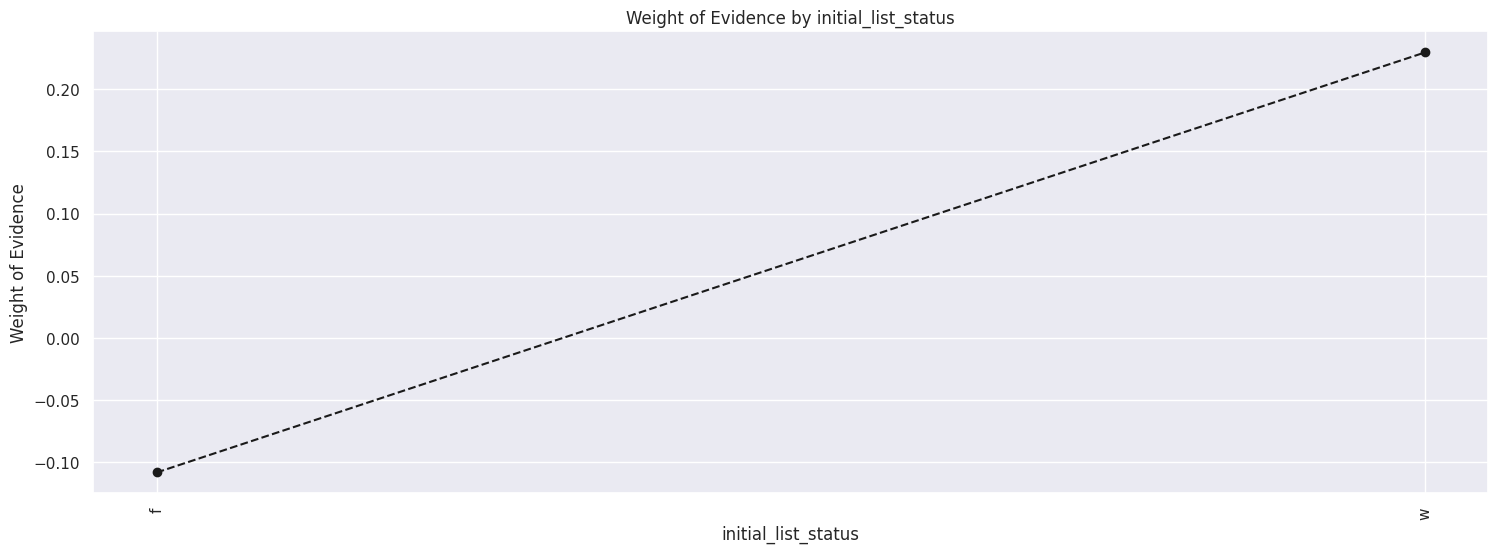

In [ ]:
plot_by_WoE(df_temp, 90)

In [ ]:
## Calculation of WoE and IV Values for Continuous Variable Function.

def woe_ordered_continuous(dataset, discrete_variable_name, dataset2):
  dataset = pd.concat([dataset[discrete_variable_name],dataset2],axis = 1)
  dataset = pd.concat([dataset.groupby(dataset.columns.values[0], as_index = False)[dataset.columns.values[1]].count(),
                       dataset.groupby(dataset.columns.values[0], as_index = False)[dataset.columns.values[1]].mean()], axis = 1)
  dataset = dataset.iloc[:,[0,1,3]]
  dataset.columns = [dataset.columns.values[0], 'n_obs', 'prop_good']
  dataset['prop_n_obs'] = dataset['n_obs'] / dataset['n_obs'].sum()
  dataset['n_good'] = dataset['prop_good'] * dataset['n_obs']
  dataset['n_bad'] = (1 - dataset['prop_good']) * dataset['n_obs']
  dataset['prop_n_good'] = dataset['n_good'] / dataset['n_good'].sum()
  dataset['prop_n_bad'] = dataset['n_bad'] / dataset['n_bad'].sum()
  dataset['WoE'] = np.log(dataset['prop_n_good']/dataset['prop_n_bad'])
  ##dataset = dataset.sort_values('WoE')
  ##dataset = dataset.reset_index(drop = True)
  dataset['diff_prop_good'] = dataset['prop_good'].diff().abs()
  dataset['diff_WoE'] = dataset['WoE'].diff().abs()
  dataset['IV'] = (dataset['prop_n_good'] - dataset['prop_n_bad']) * dataset['WoE']
  dataset['IV'] = dataset['IV'].sum()
  return dataset

In [ ]:
x_train['term_int'].unique()

array([36, 60])

In [ ]:
df_temp = woe_ordered_continuous(x_train, 'term_int', y_train)
df_temp

,term_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,36,270419,0.902995,0.724929,244187.0,26232.0,0.73495,0.643288,0.133209,NaN,NaN,0.039434
1,60,102609,0.858239,0.275071,88063.0,14546.0,0.26505,0.356712,-0.297009,0.044756,0.430218,0.039434


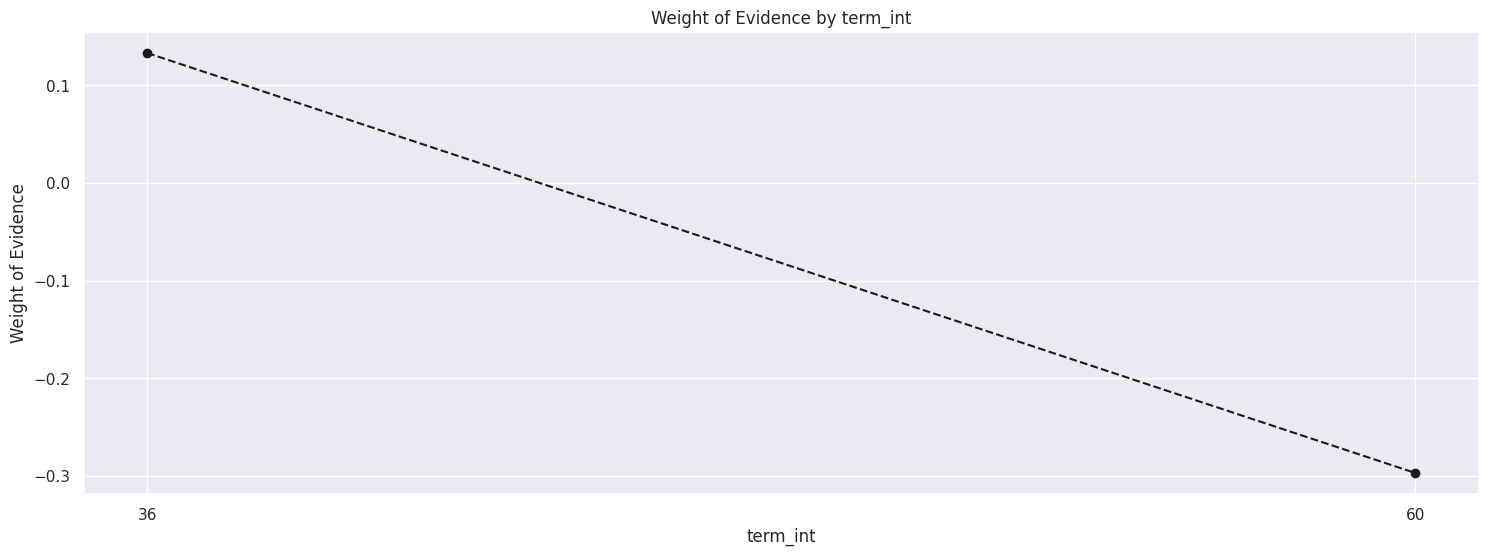

In [ ]:
plot_by_WoE(df_temp)

In [ ]:
x_train['term:36'] = (x_train['term_int'] == 36).astype(int)
x_train['term:60'] = (x_train['term_int'] == 60).astype(int)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,mnth_earliest_cr_line,issue_d_date,issue_d_date_mnth,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,sub_grade:B2,sub_grade:B3,sub_grade:B4,sub_grade:B5,sub_grade:C1,sub_grade:C2,sub_grade:C3,sub_grade:C4,sub_grade:C5,sub_grade:D1,sub_grade:D2,sub_grade:D3,sub_grade:D4,sub_grade:D5,sub_grade:E1,sub_grade:E2,sub_grade:E3,sub_grade:E4,sub_grade:E5,sub_grade:F1,sub_grade:F2,sub_grade:F3,sub_grade:F4,sub_grade:F5,sub_grade:G1,sub_grade:G2,sub_grade:G3,sub_grade:G4,sub_grade:G5,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,loan_status:Charged Off,loan_status:Current,loan_status:Default,loan_status:Does not meet the credit policy. Status:Charged Off,loan_status:Does not meet the credit policy. Status:Fully Paid,loan_status:Fully Paid,loan_status:In Grace Period,loan_status:Late (16-30 days),loan_status:Late (31-120 days),purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding,addr_state:AK,addr_state:AL,addr_state:AR,addr_state:AZ,addr_state:CA,addr_state:CO,addr_state:CT,addr_state:DC,addr_state:DE,addr_state:FL,addr_state:GA,addr_state:HI,addr_state:IA,addr_state:ID,addr_state:IL,addr_state:IN,addr_state:KS,addr_state:KY,addr_state:LA,addr_state:MA,addr_state:MD,addr_state:ME,addr_state:MI,addr_state:MN,addr_state:MO,addr_state:MS,addr_state:MT,addr_state:NC,addr_state:NE,addr_state:NH,addr_state:NJ,addr_state:NM,addr_state:NV,addr_state:NY,addr_state:OH,addr_state:OK,addr_state:OR,addr_state:PA,addr_state:RI,addr_state:SC,addr_state:SD,addr_state:TN,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w,home_ownership:RENT_OTHER_NONE ANY,addr_state:ND,addr_state:ND_NE_IA_NV_FL_HI_AL,addr_state:NM_VA,addr_state:OK_TN_MO_LA_MD_NC,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,purpose:educ__sm_b__wedd__ren_en__mov__house,purpose:oth__med__vacation,purpose:major_purch__car__home_impr,term:36
29626,29626,520869,673425,5000,5000,4848.011841,60 months,10.62,107.77,B,B3,"Village Voice Media, LLC",2 years,RENT,80000.0,Not Verified,May-10,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,"Borrower added on 05/21/10 > Hello, I plan ...",other,Legal loan,908xx,CA,4.83,0.0,Jan-05,0.0,NaN,NaN,5.0,0.0,1488,42.5,6.0,f,0.00,0.00,6418.226242,6182.83,5000.00,1418.23,0.00000,0.00,0.0000,Oct-14,971.62,NaN,Mar-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,N